# 07 — Nonlinear Gauss–Newton calibration

Stage 6 solved the inverse problem after linearising the pricing map only once
around the constant reference surface.

Stage 7 updates the linearisation repeatedly.

Let

$$
u_{\mathrm{ref}}(x,T)
=
\log\left(\sigma_{\mathrm{ref}}(x,T)^2\right)
$$

be the fixed reference, and let

$$
h=u-u_{\mathrm{ref}}
$$

be the total correction.

We minimise the nonlinear objective

$$
\Phi(u)
=
\left\|
W\left(F(u)-y\right)
\right\|^2
+
\lambda h^\top Rh.
$$


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "dupire_local_vol_project folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)


Project root: C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.synthetic_data import (
    generate_synthetic_option_data,
    save_synthetic_option_data,
)
from src.inverse.linearized_inverse import (
    run_linearized_calibration,
    weighted_rmse,
)
from src.inverse.nonlinear_inverse import (
    run_gauss_newton_calibration,
)
from src.inverse.parameterization import (
    local_volatility_from_log_variance,
    reference_log_variance_surface,
)
from src.regularization.operators import (
    build_regularization_matrix,
)
from src.regularization.potentials import (
    combine_potentials,
    confidence_potential,
    quote_confidence_surface,
    wing_potential,
)
from src.surfaces.synthetic_surfaces import (
    smile_surface,
)


## 1. Load the same synthetic option quotes

The same data, grid, weights and regularisation settings must be used so that
Stage 6 and Stage 7 are directly comparable.


In [3]:
data_path = (
    project_root
    / "data"
    / "synthetic"
    / "smile_quotes.csv"
)

if data_path.exists():
    synthetic_quotes = pd.read_csv(data_path)
    print("Loaded:", data_path)
else:
    synthetic_quotes = generate_synthetic_option_data(
        surface_function=smile_surface,
        spot=100.0,
        relative_noise=0.005,
        minimum_noise=0.01,
        random_seed=1234,
        number_of_strike_points=201,
        number_of_time_steps=160,
    )
    save_synthetic_option_data(
        synthetic_quotes,
        data_path,
    )
    print("Generated and saved:", data_path)

print("Number of quotes:", len(synthetic_quotes))


Loaded: C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project\data\synthetic\smile_quotes.csv
Number of quotes: 78


## 2. Recreate the Stage 6 calibration grid and regulariser

The reference surface remains fixed at \(20\%\). Gauss–Newton updates the
current estimate, but the penalty continues to act on the total correction

$$
h=u-u_{\mathrm{ref}}.
$$


In [4]:
spot = 100.0
rate = 0.0
dividend_yield = 0.0

calibration_maturities = np.linspace(
    0.10,
    2.00,
    5,
)
calibration_x = np.linspace(
    -0.35,
    0.35,
    9,
)

reference_log_variance = reference_log_variance_surface(
    maturities=calibration_maturities,
    log_moneyness=calibration_x,
    reference_volatility=0.20,
)

wing = wing_potential(
    log_moneyness=calibration_x,
    maturities=calibration_maturities,
    strength=0.20,
    power=2.0,
    start=0.20,
)

confidence = quote_confidence_surface(
    log_moneyness=calibration_x,
    maturities=calibration_maturities,
    quote_log_moneyness=synthetic_quotes[
        "log_moneyness"
    ].to_numpy(),
    quote_maturities=synthetic_quotes[
        "maturity"
    ].to_numpy(),
    log_moneyness_bandwidth=0.09,
    maturity_bandwidth=0.30,
)

confidence_penalty = confidence_potential(
    confidence=confidence,
    strength=0.20,
)

combined_potential = combine_potentials(
    wing,
    confidence_penalty,
)

regularization_matrix, _, _ = (
    build_regularization_matrix(
        number_of_maturities=calibration_maturities.size,
        number_of_log_moneyness_points=calibration_x.size,
        maturity_spacing=(
            calibration_maturities[1]
            - calibration_maturities[0]
        ),
        log_moneyness_spacing=(
            calibration_x[1]
            - calibration_x[0]
        ),
        alpha_x=0.005,
        alpha_T=0.002,
        beta=1e-4,
        potential=combined_potential,
    )
)

regularization_strength = 1000.0

print("Unknown log-variance values:", reference_log_variance.size)
print("R shape:", regularization_matrix.shape)


Unknown log-variance values: 45
R shape: (45, 45)


## 3. Load or recreate the Stage 6 starting surface

The Stage 6 linearised estimate is a much better starting point than the
constant reference.

If its saved output is unavailable, the notebook calculates it again.


In [5]:
stage_06_path = (
    project_root
    / "outputs"
    / "stage_06"
    / "linearized_calibration.npz"
)

use_saved_stage_06 = False

if stage_06_path.exists():
    saved_stage_06 = np.load(stage_06_path)

    grids_match = (
        np.allclose(
            saved_stage_06["calibration_maturities"],
            calibration_maturities,
        )
        and np.allclose(
            saved_stage_06["calibration_x"],
            calibration_x,
        )
    )

    if grids_match:
        initial_log_variance = saved_stage_06[
            "estimated_log_variance"
        ]
        use_saved_stage_06 = True
        print("Loaded Stage 6 estimate:", stage_06_path)

if not use_saved_stage_06:
    print("Recomputing the Stage 6 linearised estimate...")

    linearized_result = run_linearized_calibration(
        reference_log_variance=reference_log_variance,
        calibration_maturities=calibration_maturities,
        calibration_log_moneyness=calibration_x,
        quote_data=synthetic_quotes,
        regularization_matrix=regularization_matrix,
        regularization_strength=regularization_strength,
        spot=spot,
        rate=rate,
        dividend_yield=dividend_yield,
        finite_difference_step=1e-3,
        jacobian_scheme="forward",
        number_of_strike_points=151,
        number_of_time_steps=120,
        verbose=True,
    )

    initial_log_variance = linearized_result[
        "estimated_log_variance"
    ]

print("Initial surface shape:", initial_log_variance.shape)


Loaded Stage 6 estimate: C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project\outputs\stage_06\linearized_calibration.npz
Initial surface shape: (5, 9)


## 4. The Gauss–Newton update

At iteration \(k\),

$$
F(u_k+\delta)
\approx
F(u_k)+J_k\delta.
$$

The damped step solves

$$
\left(
J_k^\top W^\top WJ_k
+
\lambda R
+
\mu I
\right)\delta
=
J_k^\top W^\top W
\left(y-F(u_k)\right)
-
\lambda Rh_k.
$$

The term \(-\lambda Rh_k\) is necessary because the penalty is on the total
correction \(h_k+\delta\), not only on \(\delta\).

A backtracking line search accepts a step only when the full nonlinear
objective decreases.


In [6]:
gauss_newton_result = run_gauss_newton_calibration(
    reference_log_variance=reference_log_variance,
    initial_log_variance=initial_log_variance,
    calibration_maturities=calibration_maturities,
    calibration_log_moneyness=calibration_x,
    quote_data=synthetic_quotes,
    regularization_matrix=regularization_matrix,
    regularization_strength=regularization_strength,
    spot=spot,
    rate=rate,
    dividend_yield=dividend_yield,
    finite_difference_step=1e-3,
    jacobian_scheme="forward",
    number_of_strike_points=151,
    number_of_time_steps=120,
    maximum_iterations=4,
    initial_damping=1e-2,
    maximum_absolute_step=1.0,
    relative_objective_tolerance=1e-4,
    relative_step_tolerance=1e-3,
    verbose=True,
)

history = gauss_newton_result["history"]

print("\nStop reason:", gauss_newton_result["stop_reason"])
history


Jacobian columns completed: 4/45
Jacobian columns completed: 8/45
Jacobian columns completed: 12/45
Jacobian columns completed: 16/45
Jacobian columns completed: 20/45
Jacobian columns completed: 24/45
Jacobian columns completed: 28/45
Jacobian columns completed: 32/45
Jacobian columns completed: 36/45
Jacobian columns completed: 40/45
Jacobian columns completed: 44/45
Jacobian columns completed: 45/45
Iteration 1: objective=129.361417, weighted RMSE=1.065710, step scale=1.0000, damping=1.000e-02
Jacobian columns completed: 4/45
Jacobian columns completed: 8/45
Jacobian columns completed: 12/45
Jacobian columns completed: 16/45
Jacobian columns completed: 20/45
Jacobian columns completed: 24/45
Jacobian columns completed: 28/45
Jacobian columns completed: 32/45
Jacobian columns completed: 36/45
Jacobian columns completed: 40/45
Jacobian columns completed: 44/45
Jacobian columns completed: 45/45
Iteration 2: objective=129.338519, weighted RMSE=1.066688, step scale=1.0000, damping=3.000e

,iteration,objective,weighted_data_misfit,regularization_penalty,weighted_rmse,damping,step_scale,step_norm,relative_objective_improvement,accepted
0,0,250.978424,200.646920,0.050332,1.603869,0.010,0.0,0.000000,0.000000,True
1,1,129.361417,88.587493,0.040774,1.065710,0.010,1.0,0.075102,0.484572,True
2,2,129.338519,88.750143,0.040588,1.066688,0.003,1.0,0.003125,0.000177,True


## 5. Objective and data-fit history

The full objective should decrease at every accepted iteration.

The weighted RMSE is measured in quote-noise standard-deviation units.


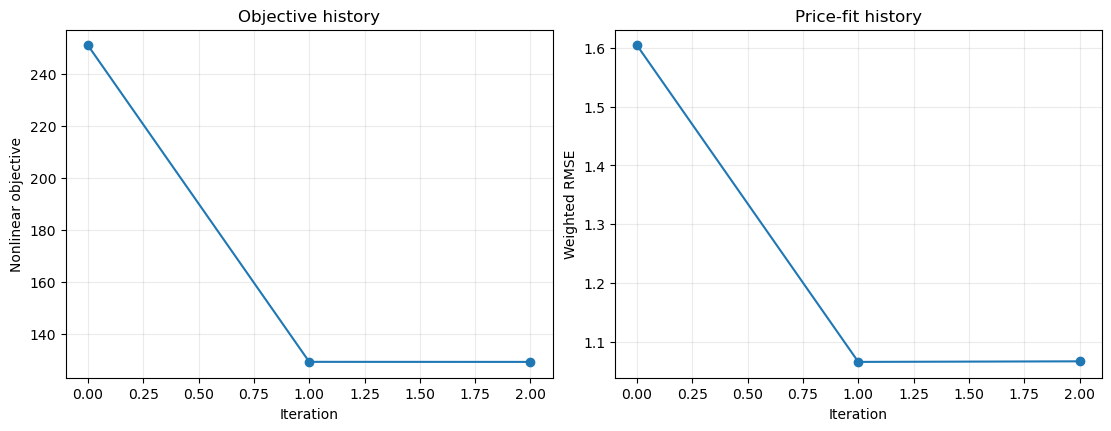

In [7]:
accepted_history = history[
    history["accepted"]
]

figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.2),
    constrained_layout=True,
)

axes[0].plot(
    accepted_history["iteration"],
    accepted_history["objective"],
    marker="o",
)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Nonlinear objective")
axes[0].set_title("Objective history")
axes[0].grid(alpha=0.25)

axes[1].plot(
    accepted_history["iteration"],
    accepted_history["weighted_rmse"],
    marker="o",
)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Weighted RMSE")
axes[1].set_title("Price-fit history")
axes[1].grid(alpha=0.25)

plt.show()


## 6. Compare starting and final repricing

The starting prices use the Stage 6 surface.

The final prices use the fully nonlinear Gauss–Newton estimate.


Stage 6 starting weighted RMSE: 1.603869
Stage 7 final weighted RMSE: 1.066688


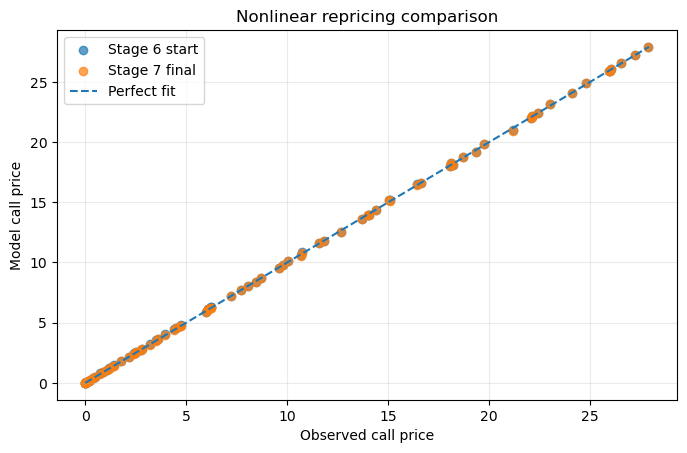

In [8]:
observed_prices = gauss_newton_result[
    "observed_prices"
]
initial_prices = gauss_newton_result[
    "initial_prices"
]
final_prices = gauss_newton_result[
    "fitted_prices"
]
weights = gauss_newton_result["weights"]

initial_weighted_rmse = weighted_rmse(
    initial_prices,
    observed_prices,
    weights,
)
final_weighted_rmse = weighted_rmse(
    final_prices,
    observed_prices,
    weights,
)

print(
    "Stage 6 starting weighted RMSE:",
    f"{initial_weighted_rmse:.6f}",
)
print(
    "Stage 7 final weighted RMSE:",
    f"{final_weighted_rmse:.6f}",
)

plt.figure(figsize=(8, 4.8))
plt.scatter(
    observed_prices,
    initial_prices,
    label="Stage 6 start",
    alpha=0.7,
)
plt.scatter(
    observed_prices,
    final_prices,
    label="Stage 7 final",
    alpha=0.7,
)

minimum_price = min(
    observed_prices.min(),
    initial_prices.min(),
    final_prices.min(),
)
maximum_price = max(
    observed_prices.max(),
    initial_prices.max(),
    final_prices.max(),
)

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    linestyle="--",
    label="Perfect fit",
)
plt.xlabel("Observed call price")
plt.ylabel("Model call price")
plt.title("Nonlinear repricing comparison")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 7. Compare the recovered surface with the truth

The comparison is made on the calibration grid, where the synthetic true
surface is known.


Stage 6 surface RMSE: 0.007092
Stage 7 surface RMSE: 0.007376


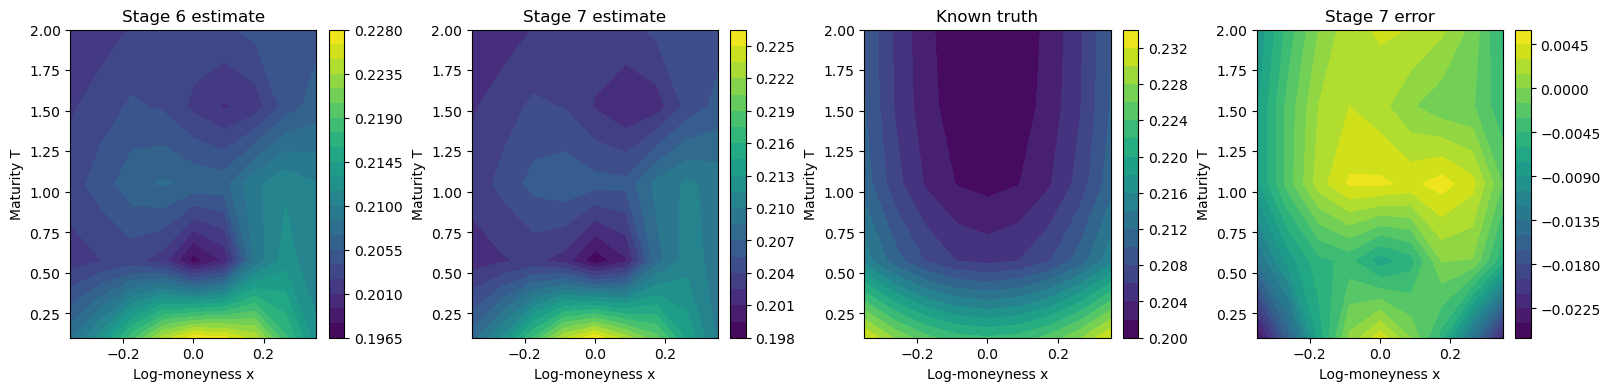

In [9]:
initial_volatility = (
    local_volatility_from_log_variance(
        initial_log_variance
    )
)
final_log_variance = gauss_newton_result[
    "estimated_log_variance"
]
final_volatility = (
    local_volatility_from_log_variance(
        final_log_variance
    )
)

x_mesh, maturity_mesh = np.meshgrid(
    calibration_x,
    calibration_maturities,
)
true_volatility = smile_surface(
    x_mesh,
    maturity_mesh,
)

initial_surface_rmse = np.sqrt(
    np.mean(
        (
            initial_volatility
            - true_volatility
        )
        ** 2
    )
)
final_surface_rmse = np.sqrt(
    np.mean(
        (
            final_volatility
            - true_volatility
        )
        ** 2
    )
)

print(
    "Stage 6 surface RMSE:",
    f"{initial_surface_rmse:.6f}",
)
print(
    "Stage 7 surface RMSE:",
    f"{final_surface_rmse:.6f}",
)

figure, axes = plt.subplots(
    1,
    4,
    figsize=(16, 3.8),
    constrained_layout=True,
)

surfaces = [
    (
        initial_volatility,
        "Stage 6 estimate",
    ),
    (
        final_volatility,
        "Stage 7 estimate",
    ),
    (
        true_volatility,
        "Known truth",
    ),
    (
        final_volatility - true_volatility,
        "Stage 7 error",
    ),
]

for axis, (surface, title) in zip(
    axes,
    surfaces,
):
    contour = axis.contourf(
        calibration_x,
        calibration_maturities,
        surface,
        levels=20,
    )
    figure.colorbar(contour, ax=axis)
    axis.set_title(title)
    axis.set_xlabel("Log-moneyness x")
    axis.set_ylabel("Maturity T")

plt.show()


## 8. Save the nonlinear calibration

The saved output will be used for diagnostics and Bayesian uncertainty in the
next stages.


In [10]:
output_directory = (
    project_root
    / "outputs"
    / "stage_07"
)
output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

output_path = (
    output_directory
    / "gauss_newton_calibration.npz"
)

np.savez_compressed(
    output_path,
    calibration_maturities=calibration_maturities,
    calibration_x=calibration_x,
    reference_log_variance=reference_log_variance,
    initial_log_variance=initial_log_variance,
    estimated_log_variance=final_log_variance,
    correction_surface=gauss_newton_result[
        "correction_surface"
    ],
    observed_prices=observed_prices,
    initial_prices=initial_prices,
    fitted_prices=final_prices,
    weights=weights,
    regularization_strength=regularization_strength,
    latest_jacobian=gauss_newton_result[
        "latest_jacobian"
    ],
    latest_singular_values=gauss_newton_result[
        "latest_singular_values"
    ],
)

history_path = (
    output_directory
    / "gauss_newton_history.csv"
)
history.to_csv(history_path, index=False)

print("Saved Stage 7 result to:")
print(output_path)
print(history_path)


Saved Stage 7 result to:
C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project\outputs\stage_07\gauss_newton_calibration.npz
C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project\outputs\stage_07\gauss_newton_history.csv


## Stage 7 result

We now have a nonlinear deterministic calibration method.

The difference from Stage 6 is that Stage 7 repeatedly:

1. prices the current surface;
2. rebuilds the pricing Jacobian;
3. solves a regularised Gauss–Newton step;
4. checks the full nonlinear objective;
5. damps or shortens the step when necessary.

The next stage will focus on tuning, diagnostics, ablation comparisons and
stability checks before uncertainty quantification is added.
